In [26]:
import pandas as pd


In [27]:
PRB_data = pd.read_csv('Base/traffic_DLPRB.csv')
PRB_data = PRB_data.drop(PRB_data.columns[0], axis=1)  # Drop the first column if it's an index or unnecessary
PRB_data.head()  # Display the first few rows of the DataFrame

,0_0_0,0_0_1,0_0_2,0_0_3,0_0_4,0_0_5,0_0_6,0_0_7,0_0_8,0_0_9,...,29_2_22,29_2_23,29_2_24,29_2_25,29_2_26,29_2_27,29_2_28,29_2_29,29_2_30,29_2_31
0,0.066698,0.085882,0.000000,0.090813,0.214019,0.317046,0.164410,0.000000,0.455932,0.149637,...,0.013303,0.000000,0.000000,0.000000,0.000000,0.123099,0.000000,0.054892,0.123654,0.057741
1,0.138920,0.256273,0.257673,0.026058,0.000000,0.151237,0.166434,0.039496,0.000000,0.000000,...,0.101364,0.044955,0.205873,0.038444,0.000000,0.107314,0.294831,0.000000,0.101475,0.056402
2,0.158870,0.000000,0.136742,0.207859,0.000000,0.009139,0.000000,0.000000,0.117079,0.000000,...,0.149791,0.009632,0.000000,0.000000,0.053097,0.000000,0.000000,0.144061,0.241812,0.165295
3,0.019840,0.000000,0.175130,0.000000,0.044551,0.000000,0.000000,0.207104,0.000000,0.055919,...,0.190656,0.000000,0.110855,0.000000,0.114978,0.090578,0.000000,0.037659,0.200538,0.111626
4,0.087727,0.152698,0.065651,0.020144,0.000000,0.111326,0.318864,0.000000,0.199769,0.054351,...,0.454085,0.000000,0.009313,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.106244


In [28]:
cell_cols = {}
for col in PRB_data.columns:
    parts = col.split('_')
    bs, cell, beam = parts[0], parts[1], parts[2]
    key = f"{bs}_{cell}"
    cell_cols.setdefault(key, []).append(col)

# Sum beams for each cell
cell_data = {}
for cell_key, cols in cell_cols.items():
    cell_data[cell_key] = PRB_data[cols].sum(axis=1)

cell_PRB_df = pd.DataFrame(cell_data)

# Relabel columns to C1, C2, ... C90
cell_PRB_df.columns = [f"C{i+1}" for i in range(len(cell_PRB_df.columns))]

In [29]:
cell_PRB_df.head()  # Display the first few rows of the new DataFrame

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,...,C81,C82,C83,C84,C85,C86,C87,C88,C89,C90
0,3.597879,2.263070,2.536997,1.767760,1.861057,1.922795,2.927855,2.055274,2.617039,2.560400,...,1.215159,0.650592,1.304670,1.603881,2.229107,2.191400,1.295968,1.808825,1.598069,2.252928
1,2.804197,1.845998,2.420828,1.637078,1.171218,1.946756,2.292398,1.396858,1.786607,2.391954,...,2.659069,1.256097,2.051581,1.603982,2.596555,1.418913,1.276000,3.883666,1.842837,1.937998
2,1.854696,2.361856,1.836115,1.799294,2.031284,1.891162,1.712333,1.115131,3.026528,1.796631,...,1.608693,1.408412,1.851250,1.730058,3.029380,2.378878,1.604257,1.473055,1.840397,1.910943
3,2.074821,1.934856,4.769888,2.592996,8.567154,8.421780,2.304716,3.221027,10.187385,2.593069,...,2.121308,2.417024,8.823012,5.306943,6.314380,1.632400,2.896760,4.669593,5.848477,2.307870
4,2.673236,5.798783,3.702238,3.698515,9.849255,9.479258,3.378446,4.815367,7.196895,1.694802,...,1.948843,5.882658,6.874128,6.532096,6.119528,2.530514,1.694510,2.770702,4.879375,1.902079


In [30]:
# divide each cell by 32 since each cell has 32 beams
cell_PRB_df = cell_PRB_df / 32

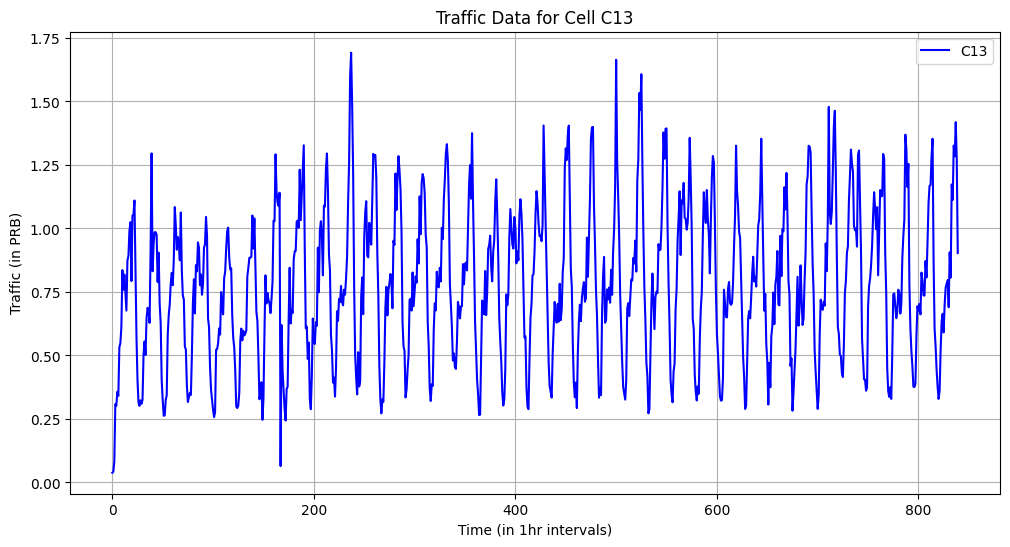

In [31]:
# plot C1 as a line plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(cell_PRB_df['C13'], label='C13', color='blue')   
plt.title('Traffic Data for Cell C13')
plt.xlabel('Time (in 1hr intervals)')
plt.ylabel('Traffic (in PRB)')
plt.legend()
plt.grid()
plt.show()


In [32]:
# import MR number data
MR_data = pd.read_csv('Base/traffic_MR_number.csv')
MR_data = MR_data.drop(MR_data.columns[0], axis=1)  # Drop the first column if it's an index or unnecessary
MR_data.head() 


,0_0_0,0_0_1,0_0_2,0_0_3,0_0_4,0_0_5,0_0_6,0_0_7,0_0_8,0_0_9,...,29_2_22,29_2_23,29_2_24,29_2_25,29_2_26,29_2_27,29_2_28,29_2_29,29_2_30,29_2_31
0,0.000000,0.000000,0.000000,0.027642,0.055997,0.0,0.000000,0.000000,0.016494,0.000000,...,0.132844,0.000000,0.000000,0.197986,0.057834,0.000000,0.054223,0.000000,0.000000,0.000000
1,0.000000,0.152042,0.000000,0.000000,0.000000,0.0,0.010041,0.000000,0.000000,0.103261,...,0.000000,0.000000,0.000000,0.200403,0.114988,0.000000,0.000000,0.000000,0.000000,0.131941
2,0.173515,0.227844,0.000000,0.007925,0.000000,0.0,0.056169,0.000000,0.167527,0.000000,...,0.000000,0.005662,0.000000,0.158079,0.000000,0.085078,0.236631,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.030259,0.010449,0.098800,0.0,0.000000,0.000000,0.286327,0.000000,...,0.158921,0.074785,0.000000,0.000000,0.217637,0.031042,0.000000,0.145658,0.046112,0.181847
4,0.062068,0.000000,0.179430,0.000000,0.184392,0.0,0.244443,0.078096,0.079690,0.251222,...,0.137332,0.000000,0.350005,0.000000,0.021422,0.195442,0.114019,0.111869,0.000000,0.042406


In [33]:
cell_cols = {}
for col in MR_data.columns:
    parts = col.split('_')
    bs, cell, beam = parts[0], parts[1], parts[2]
    key = f"{bs}_{cell}"
    cell_cols.setdefault(key, []).append(col)

# Sum beams for each cell
cell_MR_data = {}
for cell_key, cols in cell_cols.items():
    cell_MR_data[cell_key] = MR_data[cols].sum(axis=1)

cell_MR_df = pd.DataFrame(cell_MR_data)

# Relabel columns to C1, C2, ... C90
cell_MR_df.columns = [f"C{i+1}" for i in range(len(cell_MR_df.columns))]

In [34]:
Cell_MR_df = cell_MR_df/32

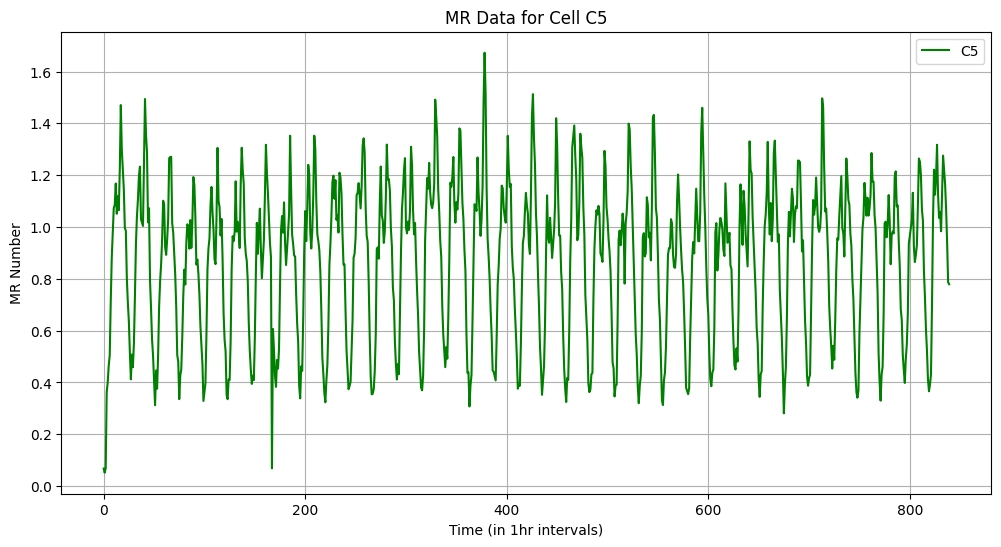

In [35]:
# plot the C1 MR data as a line plot
plt.figure(figsize=(12, 6))
plt.plot(Cell_MR_df['C5'], label='C5', color='green')
plt.title('MR Data for Cell C5')
plt.xlabel('Time (in 1hr intervals)')
plt.ylabel('MR Number')
plt.legend()
plt.grid()
plt.show()

In [36]:
cell_means = cell_MR_df.mean(axis=0)  # mean load per cell
macro_candidates = cell_means.nlargest(7).index.tolist()
# e.g. ['C12', 'C45', 'C3', ...]
macro_candidates

['C54', 'C20', 'C60', 'C46', 'C77', 'C80', 'C13']

In [37]:
# micro_candidates = 39 cells from 1 that are not in macro_candidates
all_cells = set(cell_MR_df.columns)
micro_candidates = list(all_cells - set(macro_candidates)) 
micro_candidates = sorted(micro_candidates)  # Sort for consistency
micro_candidates = micro_candidates[:39] # Select the first 39 cells
micro_candidates

['C1',
 'C10',
 'C11',
 'C12',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'C19',
 'C2',
 'C21',
 'C22',
 'C23',
 'C24',
 'C25',
 'C26',
 'C27',
 'C28',
 'C29',
 'C3',
 'C30',
 'C31',
 'C32',
 'C33',
 'C34',
 'C35',
 'C36',
 'C37',
 'C38',
 'C39',
 'C4',
 'C40',
 'C41',
 'C42',
 'C43',
 'C44',
 'C45',
 'C47']

In [38]:
Chosen_cells = macro_candidates + micro_candidates
len(Chosen_cells)  # Should be 46

46

In [39]:
# normalise PRB data and MR data to [0, 1] range per column
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cell_PRB_df[Chosen_cells] = scaler.fit_transform(cell_PRB_df[Chosen_cells])
cell_MR_df[Chosen_cells] = scaler.fit_transform(cell_MR_df[Chosen_cells])

In [40]:
# remove the cells that are not in Chosen_cells from both dataframes
cell_PRB_df = cell_PRB_df[Chosen_cells]
cell_MR_df = cell_MR_df[Chosen_cells]

In [41]:
# import the final_topology dataset
final_topology_df = pd.read_csv("Opencellid/final_topology.csv")
final_topology_df.head()  # Display the first few rows of the final topology DataFrame

,CellID,Latitude,Longitude,Macro
0,C1,51.5266,-0.1338,M3
1,C2,51.5248,-0.1359,M1
2,C3,51.5250,-0.1275,M6
3,C4,51.5260,-0.1345,M3
4,C5,51.5255,-0.1327,M4


In [42]:
cell_ids = final_topology_df['CellID'].tolist()
cell_ids

['C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'M5',
 'C9',
 'C10',
 'C11',
 'C12',
 'M1',
 'C14',
 'C15',
 'C16',
 'C17',
 'C18',
 'M4',
 'C20',
 'C21',
 'C22',
 'C23',
 'C24',
 'C25',
 'C26',
 'C27',
 'C28',
 'C29',
 'C30',
 'C31',
 'C32',
 'M6',
 'C34',
 'C35',
 'M3',
 'C37',
 'C38',
 'C39',
 'C40',
 'C41',
 'C42',
 'C43',
 'M7',
 'C45',
 'M2']

In [43]:
# name the first 7 columns as M1, M2, ..., M7 as macro cells in Cell_PRB_df and Cell_MR_df
macro_cell_mapping = {macro_candidates[i]: f"M{i+1}" for i in range(len(macro_candidates))}
cell_PRB_df.rename(columns=macro_cell_mapping, inplace=True)
cell_MR_df.rename(columns=macro_cell_mapping, inplace=True)

In [44]:
# from the 8th column onwards, name them as in order of cellid as micro cells excluding the Macro cells which have Ids M1 to M7
micro_cell_mapping = {micro_candidates[i]: f"C{i+1}" for i in range(len(micro_candidates))}
cell_PRB_df.rename(columns=micro_cell_mapping, inplace=True)
cell_MR_df.rename(columns=micro_cell_mapping, inplace=True)

In [45]:
# take the cellid of the micro cells from cellid where the names start with C and are in the micro_candidates list

micro_cell_ids = [cell_id for cell_id in cell_ids if cell_id.startswith('C') ]   
len(micro_cell_ids)

39

In [46]:
# rename the last 39 columns in cell_PRB_df and cell_MR_df to the ids in micro_cell_ids as it is

cell_PRB_df.columns = list(cell_PRB_df.columns[:7]) + micro_cell_ids
cell_MR_df.columns = list(cell_MR_df.columns[:7]) + micro_cell_ids


In [47]:
cell_PRB_df.head()  # Display the first few rows of the final PRB DataFrame


,M1,M2,M3,M4,M5,M6,M7,C1,C2,C3,...,C34,C35,C37,C38,C39,C40,C41,C42,C43,C45
0,0.008058,0.013740,0.009675,0.000000,0.009363,0.005092,0.000000,0.056662,0.037819,0.022926,...,0.000000,0.034936,0.019216,0.023488,0.000000,0.004554,0.014522,0.004956,0.029742,0.024185
1,0.004221,0.000000,0.000000,0.004946,0.021248,0.002824,0.002028,0.035630,0.033872,0.000000,...,0.026810,0.026299,0.014469,0.011347,0.040983,0.001568,0.039723,0.022426,0.031261,0.009694
2,0.000000,0.007940,0.002991,0.018961,0.000000,0.013840,0.026764,0.010470,0.019922,0.011584,...,0.029568,0.041499,0.020362,0.003930,0.000886,0.018614,0.016617,0.000000,0.033830,0.000000
3,0.206967,0.149325,0.071525,0.142299,0.180622,0.050677,0.163374,0.016303,0.038585,0.069067,...,0.089639,0.245986,0.049193,0.026345,0.273397,0.267802,0.188336,0.054694,0.176755,0.198021
4,0.145668,0.091018,0.091081,0.097151,0.127565,0.021200,0.159419,0.032160,0.017536,0.043722,...,0.161246,0.301755,0.089351,0.045312,0.378863,0.240062,0.154120,0.016449,0.141221,0.188843


In [48]:
# save the processed dataframes to CSV files for later use
cell_PRB_df.to_csv("Base/processed_cell_PRB.csv", index=False)
cell_MR_df.to_csv("Base/processed_cell_MR.csv", index=False)

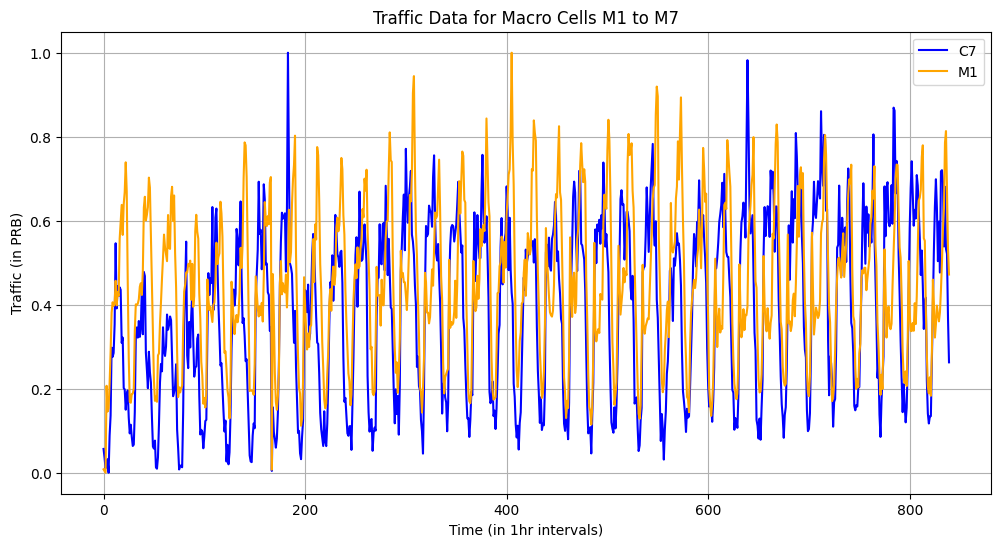

In [54]:
# plot a line plot of the first 7 macro cells in cell_PRB_df
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(cell_PRB_df['C1'], label='C7', color='blue')
plt.plot(cell_PRB_df['M1'], label='M1', color='orange')
plt.title('Traffic Data for Macro Cells M1 to M7')
plt.xlabel('Time (in 1hr intervals)')
plt.ylabel('Traffic (in PRB)')
plt.legend()
plt.grid()
plt.show()